In [1]:
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt

df1 = pd.read_excel("accesos.xlsx")
print(f'Tamaño del Dataframe: {df1.shape}')
df1.head()

Tamaño del Dataframe: (50376, 35)


,Linea,Estacion,Acceso_Estacion,Intervalo,_2025_06_01,_2025_06_02,_2025_06_03,_2025_06_04,_2025_06_05,_2025_06_06,...,_2025_06_22,_2025_06_23,_2025_06_24,_2025_06_25,_2025_06_26,_2025_06_27,_2025_06_28,_2025_06_29,_2025_06_30,total_general
0,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,00:00:00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,00:15:00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,00:30:00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,00:45:00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,01:00:00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [2]:
df_estaciones = pd.read_csv("estaciones2.csv")
print(f'Tamaño del Dataframe: {df_estaciones.shape}')
df_estaciones.head()

Tamaño del Dataframe: (153, 29)


,X,Y,observ,longitud,latitud,objectid,num_est,nom_est,id_trazado,long_est,...,acc_puent,cod_nodo,cap_biart,num_vag,cap_art,globalid,created_user,created_date,last_edited_user,last_edited_date
0,1.000325e+06,1.007758e+06,Valores de capacidad de buses en proceso de ac...,-74.074575,4.666353,624,7103,AV. Chile,TZ008,173.64,...,2,7103,120,3,224,{88CDEE8D-FC67-43E6-B91B-1385BB3BD488},NaN,NaN,NaN,NaN
1,9.976102e+05,1.005604e+06,Valores de capacidad de buses en proceso de ac...,-74.099046,4.646876,625,6103,CAN,TZ016,96.48,...,1,6103,120,2,140,{D7AC3687-AAC2-4153-801B-6DB705329D88},NaN,NaN,NaN,NaN
2,9.998666e+05,1.005440e+06,Valores de capacidad de buses en proceso de ac...,-74.078710,4.645398,626,7106,Campín - UAN,TZ008,122.82,...,2,7106,120,2,152,{992C8526-1970-4933-9EB9-826D966F6999},NaN,NaN,NaN,NaN
3,1.000667e+06,1.001625e+06,Valores de capacidad de buses en proceso de ac...,-74.071500,4.610899,627,10008,San Diego,TZ018,348.09,...,0,10008,144,2,144,{667C3BFD-2FBE-40E7-AC18-8D327C4F17DF},NaN,NaN,NaN,NaN
4,9.979464e+05,1.011384e+06,Valores de capacidad de buses en proceso de ac...,-74.096018,4.699151,628,4100,Granja - Kr 77,TZ005,385.00,...,1,4100,144,4,248,{5BB6ECCC-FCBC-474C-8399-84E490AC3502},NaN,NaN,NaN,NaN


# Registro de Salidas
## 1) Conocimiento Inicial de los Datos
### Significado de variables
- Linea: Linea troncal a la que pertenece la estación. TIPO CATEGÓRICO
- Estacion: Nombre de la estación. TIPO CATEGÓRICO
- Acceso_Estacion: Nombre del acceso a la estación. TIPO CATEGÓRICO
- Intervalo: Hora del día, cada 15 min. TIPO CATEGÓRICO
- _2025_06_01: Día del mes de junio, número de salidas registradas. TIPO NUMÉRICO
- total_general: Total de salidas registradas. TIPO NUMÉRICO

Hay una columna para cada día en las que se registran el número de salidas de la estación siguiendo la siguiente agrupación

Linea --> Estacion --> Acceso_Estacion --> Intervalo

## 2) Diagnóstico de Calidad de Datos

### - Datos faltantes
Se observa que hay un total de 50376 datos, entre las variables solo se hallan 35 datos nulos en Acceso_Estacion.

In [3]:
df1.isna().sum()

Linea               0
Estacion            0
Acceso_Estacion    35
Intervalo           0
_2025_06_01         0
_2025_06_02         0
_2025_06_03         0
_2025_06_04         0
_2025_06_05         0
_2025_06_06         0
_2025_06_07         0
_2025_06_08         0
_2025_06_09         0
_2025_06_10         0
_2025_06_11         0
_2025_06_12         0
_2025_06_13         0
_2025_06_14         0
_2025_06_15         0
_2025_06_16         0
_2025_06_17         0
_2025_06_18         0
_2025_06_19         0
_2025_06_20         0
_2025_06_21         0
_2025_06_22         0
_2025_06_23         0
_2025_06_24         0
_2025_06_25         0
_2025_06_26         0
_2025_06_27         0
_2025_06_28         0
_2025_06_29         0
_2025_06_30         0
total_general       0
dtype: int64

In [4]:
df1_null = df1[df1["Acceso_Estacion"].isnull()]
df1_null['Estacion'].unique()

<StringArray>
['(09111)Calle 19']
Length: 1, dtype: str

Los datos faltantes son de la estación Calle 19. Esta estación fue cerrada el 8 de marzo del 2025, por lo que no tiene sentido conservarla, se puede borrar

In [5]:
df1.describe()

,_2025_06_01,_2025_06_02,_2025_06_03,_2025_06_04,_2025_06_05,_2025_06_06,_2025_06_07,_2025_06_08,_2025_06_09,_2025_06_10,...,_2025_06_22,_2025_06_23,_2025_06_24,_2025_06_25,_2025_06_26,_2025_06_27,_2025_06_28,_2025_06_29,_2025_06_30,total_general
count,50376.000000,50376.000000,50376.000000,50376.000000,50376.000000,50376.000000,50376.000000,50376.000000,50376.000000,50376.000000,...,50376.000000,50376.000000,50376.000000,50376.000000,50376.000000,50376.000000,50376.000000,50376.000000,50376.000000,50376.000000
mean,17.331428,15.146875,46.091929,45.597963,45.371586,44.166925,32.867040,16.920438,42.890841,44.101417,...,17.247300,15.884687,44.874305,45.647173,44.024397,43.003831,31.528625,18.427624,15.284004,1029.459108
std,39.070495,34.073168,110.883625,109.077056,107.173819,101.790797,67.268618,38.974170,104.024625,106.880440,...,38.426476,35.462844,106.119548,106.102967,104.280590,98.126315,65.947475,43.742706,34.891800,2297.153715
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,14.000000
75%,17.000000,16.000000,43.000000,43.000000,44.000000,44.000000,36.000000,18.000000,40.000000,41.000000,...,18.000000,17.000000,44.000000,45.000000,42.000000,42.000000,33.000000,18.000000,15.000000,1072.000000
max,616.000000,534.000000,1728.000000,1604.000000,1741.000000,1610.000000,722.000000,826.000000,1848.000000,1662.000000,...,693.000000,554.000000,1751.000000,1590.000000,1597.000000,1446.000000,835.000000,911.000000,515.000000,31700.000000


Se observa un comportamiento extraño en los dos primeros cuartiles, el primero es igual al mínimo y el segundo prácticamente igual; difieren mucho del dato máximo y del 3er cuartil.

La desviación estandar es más del doble de la media, lo cual indica datos demaciado dispersos y la presencia de muchos outliers.

### - Datos Atípicos
Se observa que en prácticamente todos los días se hayan datos atípicos, esto se debe a que Bogotá posee horas pico muy marcadas, mientras que en el resto del prácticamente no hay flujo de personas. También se puede deber a la presencia de registros en horas donde no opera el servicio de Transmilenio y/o estaciones cerradas, aumentando la cantidad de registros donde no se reportan salidas.

Text(0.5, 1.0, 'Total de Salidas registradas por Linea Troncal')

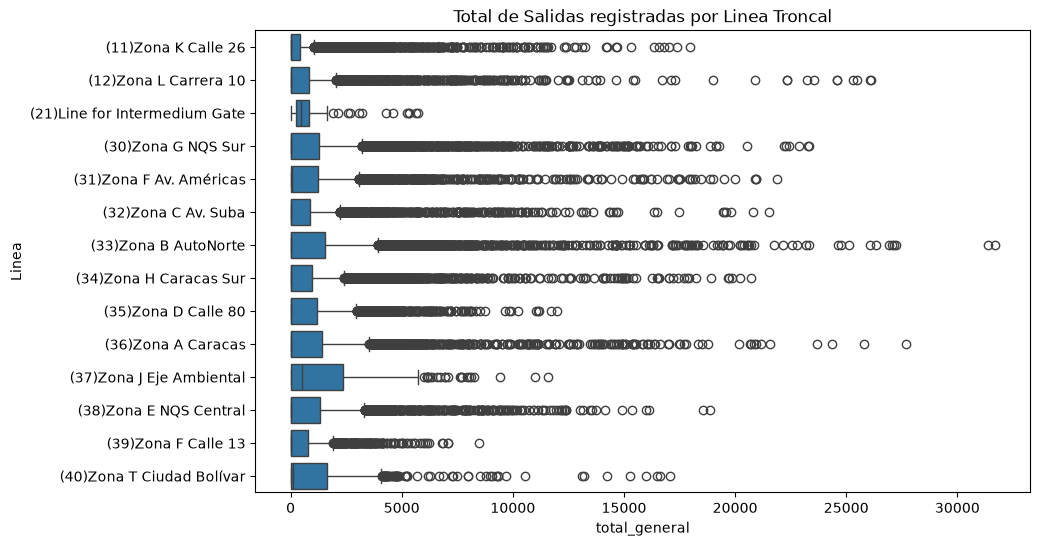

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df1, x="total_general", y="Linea")
plt.title("Total de Salidas registradas por Linea Troncal")

In [7]:
df1['Intervalo'].unique()

<StringArray>
['00:00:00', '00:15:00', '00:30:00', '00:45:00', '01:00:00', '03:00:00',
 '03:15:00', '03:30:00', '03:45:00', '04:00:00', '04:15:00', '04:30:00',
 '04:45:00', '05:00:00', '05:15:00', '05:30:00', '05:45:00', '06:00:00',
 '06:15:00', '06:30:00', '06:45:00', '07:00:00', '07:15:00', '07:30:00',
 '07:45:00', '08:00:00', '08:15:00', '08:30:00', '08:45:00', '09:00:00',
 '09:15:00', '09:30:00', '09:45:00', '10:00:00', '10:15:00', '10:30:00',
 '10:45:00', '11:00:00', '11:15:00', '11:30:00', '11:45:00', '12:00:00',
 '12:15:00', '12:30:00', '12:45:00', '13:00:00', '13:15:00', '13:30:00',
 '13:45:00', '14:00:00', '14:15:00', '14:30:00', '14:45:00', '15:00:00',
 '15:15:00', '15:30:00', '15:45:00', '16:00:00', '16:15:00', '16:30:00',
 '16:45:00', '17:00:00', '17:15:00', '17:30:00', '17:45:00', '18:00:00',
 '18:15:00', '18:30:00', '18:45:00', '19:00:00', '19:15:00', '19:30:00',
 '19:45:00', '20:00:00', '20:15:00', '20:30:00', '20:45:00', '21:00:00',
 '21:15:00', '21:30:00', '21:45:00', 

Se puede ver que se incluyen registros de horas en las que transmilenio no opera. De acuerdo a la página de transmilenio los horarios de operación son:
- Lunes a viernes: 4:00 - 23:00
- Sábados: 5:00 - 23:00
- Domingos y festivos: 5:00 - 22:00

Por lo que es de esperarse que en varias de las horas registradas no se reporten salidas. Dado que el análisis se centra en los horarios de operación de transmilenio, se pueden borrar los registros que salgan del horario de 4:00 - 23:00 (el más largo y el que más se repite).

# Registro de Estaciones
## 1) Conocimiento inicial de los datos
### Significado de variables

- X: Coordenada X (Este) de la ubicación geográfica del elemento. NUMÉRICO
- Y: Coordenada Y (Norte) de la ubicación geográfica del elemento. NUMÉRICO
- longitud: Longitud geográfica de localización del elemento. NUMÉRICO
- latitud: Latitud geográfica de localización del elemento. NUMÉRICO
- nom_est: Nombre completo de la estación troncal. CATEGÓRICO
- id_trazado: Identificador del trazado troncal asociado a la estación. CATEGÓRICO
- eta_oper: Correspoden a la etapa actual en la operación, donde: 1. Operativa; 2. Operativa con obras; 3. Cierre temporal Obras; 4. Cierre temporal - Otros. NUMÉRICO
- tipo_esta: Corresponde al tipo o categoría de la estación, donde: 1. Portal; 2. Intermedia; 3. Intercambio; 4. Sencilla; 5. Por definir. NUMÉRICO
- ub_est: Referencia a las vías principales donde se ubica la estación. CATEGÓRICO
- num_acc: Cantidad total de accesos de la estación. NUMÉRICO
- num_vag: Cantidad de vagones que componen la estación. NUMÉRICO

Se extraen las columnas relevantes para el estudio

In [8]:
df2 = df_estaciones[["X", "Y", "latitud", "longitud", "nom_est", "id_trazado", "ub_est", "tipo_esta", "num_vag", "num_acc", "eta_oper"]]
df2.head()

,X,Y,latitud,longitud,nom_est,id_trazado,ub_est,tipo_esta,num_vag,num_acc,eta_oper
0,1.000325e+06,1.007758e+06,4.666353,-74.074575,AV. Chile,TZ008,KR 30 - CL 72,4,3,2,1
1,9.976102e+05,1.005604e+06,4.646876,-74.099046,CAN,TZ016,KR 60,4,2,1,1
2,9.998666e+05,1.005440e+06,4.645398,-74.078710,Campín - UAN,TZ008,KR 30 - CL 53,4,2,2,1
3,1.000667e+06,1.001625e+06,4.610899,-74.071500,San Diego,TZ018,KR 10 - CL 23,4,2,2,1
4,9.979464e+05,1.011384e+06,4.699151,-74.096018,Granja - Kr 77,TZ005,KR 77 Bis,2,4,2,1


In [9]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   X           153 non-null    float64
 1   Y           153 non-null    float64
 2   latitud     153 non-null    float64
 3   longitud    153 non-null    float64
 4   nom_est     153 non-null    str    
 5   id_trazado  153 non-null    str    
 6   ub_est      153 non-null    str    
 7   tipo_esta   153 non-null    int64  
 8   num_vag     153 non-null    int64  
 9   num_acc     153 non-null    int64  
 10  eta_oper    153 non-null    int64  
dtypes: float64(4), int64(4), str(3)
memory usage: 13.3 KB


## 2) Diagnóstico de calidad de datos
### - Datos faltantes
No hay datos faltantes

### - Datos atípicos

In [10]:
df2.describe(include = 'str').T

,count,unique,top,freq
nom_est,153,152,Temporal AV. Jiménez - Inter Eléctricas,2
id_trazado,153,17,TZ009,17
ub_est,153,147,Soacha,5


In [11]:
df2[df2['nom_est'] == 'Temporal AV. Jiménez - Inter Eléctricas']

,X,Y,latitud,longitud,nom_est,id_trazado,ub_est,tipo_esta,num_vag,num_acc,eta_oper
70,999465.3104,1.000439e+06,4.602867,-74.080410,Temporal AV. Jiménez - Inter Eléctricas,TZ001,CL 13 - CL 11,3,3,2,1
85,999837.9424,1.000747e+06,4.603053,-74.079093,Temporal AV. Jiménez - Inter Eléctricas,TZ015,CL 13 - Caracas,3,5,1,1


In [12]:
df1[df1["Estacion"].str.contains("jimenez", case=False, na=False)]["Estacion"].unique()

<StringArray>
['(09110)Avenida Jimenez']
Length: 1, dtype: str

La estación de la AV.Jimenez se repite, debido a que hay una en la Caracas y otra en la Calle 13. Pero en los dos dataframes se encuentran de la misma manera por lo que puede dejarse así. 

In [13]:
df1['Estacion'].unique()

<StringArray>
[  '(06000)Portal El Dorado - C.C. NUESTRO BOGOTA',
                                  '(06001)Modelia',
                                '(06002)Normandía',
                 '(06100)Av. Rojas – UNISALESIANA',
 '(06101)El Tiempo - Camara de Comercio de Bogota',
                         '(06102)Salitre El Greco',
            '(06102)Salitre El Greco - Vive Claro',
                    '(06103)CAN - British Council',
                              '(06104)Gobernación',
                           '(06105)Quinta Paredes',
 ...
                         '(12002)CDS - Carrera 32',
                                 '(12003)Ricaurte',
                               '(12004)Carrera 22',
                          '(12007)Zona Industrial',
                                '(14001)La Sabana',
                       '(40000)Cable Portal Tunal',
                            '(40001)Juan Pablo II',
                                  '(40002)Manitas',
                      '(40003)Mirador del Par

In [14]:
df2['nom_est'].unique()

<StringArray>
[                        'AV. Chile',                               'CAN',
                      'Campín - UAN',                         'San Diego',
                    'Granja - Kr 77',                    'Ricaurte - NQS',
                          'Quirigua',                  'Suba - Calle 100',
                 'Calle 75 - Zona M',                        'AV. Boyacá',
 ...
                 'Temporal Calle 34',                           'Venecia',
                           'Danubio', 'Portal Sur - JFK Coop. Financiera',
                 'Temporal Calle 22',                   'Temporal AV. 39',
       'Temporal Flores – Areandina',              'Tibanica - Primavera',
                      'Los Laureles',                          'Islandia']
Length: 152, dtype: str

Hay una inconsistencia en el número de estaciones que hay registradas en los dos dataframes. Esto puede deberse a la presencia de estaciones cerradas o duplicadas. También porque se incluyen como estaciones a parte ciertas zonas de portales o estaciones intermedias.

# Limpieza de Datos (Registro de Salidas)

## - Registros fuera de horario

Ahora hay que eliminar los registros de horas fuera del horario de operación.

Accederemos a las horas que se necesitan borrar desde el dataframe principal (df1) para borrar los del dataframe limpio (df1_clean)

In [15]:
df1_clean = df1.copy()

#Eliminar las horas de 00:00:00 a 03:45:00
for i in range(0, 9):
    df1_clean = df1_clean[df1_clean['Intervalo'] != df1.loc[i, "Intervalo"]]


In [16]:
#Eliminar las horas de 23:15:00 a 23:45:00
for i in range(86, 89):
    df1_clean = df1_clean[df1_clean['Intervalo'] != df1.loc[i, "Intervalo"]]

In [17]:
df1_clean = df1_clean[ (df1_clean['Intervalo'] != '02:30:00') & (df1_clean['Intervalo'] != '02:45:00') ]

In [18]:
df1_clean.reset_index()
df1_clean['Intervalo'].unique()

<StringArray>
['04:00:00', '04:15:00', '04:30:00', '04:45:00', '05:00:00', '05:15:00',
 '05:30:00', '05:45:00', '06:00:00', '06:15:00', '06:30:00', '06:45:00',
 '07:00:00', '07:15:00', '07:30:00', '07:45:00', '08:00:00', '08:15:00',
 '08:30:00', '08:45:00', '09:00:00', '09:15:00', '09:30:00', '09:45:00',
 '10:00:00', '10:15:00', '10:30:00', '10:45:00', '11:00:00', '11:15:00',
 '11:30:00', '11:45:00', '12:00:00', '12:15:00', '12:30:00', '12:45:00',
 '13:00:00', '13:15:00', '13:30:00', '13:45:00', '14:00:00', '14:15:00',
 '14:30:00', '14:45:00', '15:00:00', '15:15:00', '15:30:00', '15:45:00',
 '16:00:00', '16:15:00', '16:30:00', '16:45:00', '17:00:00', '17:15:00',
 '17:30:00', '17:45:00', '18:00:00', '18:15:00', '18:30:00', '18:45:00',
 '19:00:00', '19:15:00', '19:30:00', '19:45:00', '20:00:00', '20:15:00',
 '20:30:00', '20:45:00', '21:00:00', '21:15:00', '21:30:00', '21:45:00',
 '22:00:00', '22:15:00', '22:30:00', '22:45:00', '23:00:00']
Length: 77, dtype: str

Ahora solo se contienen los datos de las horas en las que opera transmilenio

La linea troncal F esta separada entre calle 13 y Av. Américas, se pueden juntar en una sola por conveniencia

In [19]:
df1_clean['Linea'].unique()

<StringArray>
[          '(11)Zona K Calle 26',         '(12)Zona L Carrera 10',
 '(21)Line for Intermedium Gate',            '(30)Zona G NQS Sur',
       '(31)Zona F Av. Américas',           '(32)Zona C Av. Suba',
          '(33)Zona B AutoNorte',        '(34)Zona H Caracas Sur',
           '(35)Zona D Calle 80',            '(36)Zona A Caracas',
      '(37)Zona J Eje Ambiental',        '(38)Zona E NQS Central',
           '(39)Zona F Calle 13',     '(40)Zona T Ciudad Bolívar']
Length: 14, dtype: str

In [20]:
# Poner todas las estaciones del mismo nombre
df1_clean['Linea'] = df1_clean['Linea'].replace(
    '(39)Zona F Calle 13', 
    '(31)Zona F Av. Américas'
)

# Agrupar especificando todas las columnas para evitar perder el orden del dataframe
# as_index=False mantiene las columnas agrupadas como columnas normales
df1_clean = df1_clean.groupby(
    ['Linea', 'Estacion', 'Acceso_Estacion', 'Intervalo'], 
    as_index=False
).sum(numeric_only=True)

df1_clean['Linea'].unique()

<StringArray>
[          '(11)Zona K Calle 26',         '(12)Zona L Carrera 10',
 '(21)Line for Intermedium Gate',            '(30)Zona G NQS Sur',
       '(31)Zona F Av. Américas',           '(32)Zona C Av. Suba',
          '(33)Zona B AutoNorte',        '(34)Zona H Caracas Sur',
           '(35)Zona D Calle 80',            '(36)Zona A Caracas',
      '(37)Zona J Eje Ambiental',        '(38)Zona E NQS Central',
     '(40)Zona T Ciudad Bolívar']
Length: 13, dtype: str

## - Influencia de los accesos para discapacitados

In [21]:
df1_clean['Acceso_Estacion'].unique()

<StringArray>
['(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO/VILLEMAR/CALIHAYUELOS/LAESTANCIA/ZONA FRANCA/BELÉN-TC6',
       '(02) PLAT1 ALIM-ENGATIVÁ/LAFAENA/TIERRAGRATA/AEROPUERTO/ELMUELLE/AV.ELDORADO ALAMOS/VILLAAMALIA',
                                                                         '(03) Acceso Peatonal Oriental',
                                                                       '(04) Acceso Peatonal Occidental',
                                                          '(18) Acceso Peatonal Oriental (Discapacidad)',
                                                        '(19) Acceso Peatonal Occidental (Discapacidad)',
                                                                               '(20) Acceso Bicicletero',
                                                                  '(21) Acceso Túnel PLAT1 Alimentación',
                                                   '(22) Acceso Túnel PLAT1 Alimentación (Discapacidad)',
                                

El dataframe cuenta por separado las salidas registradas en accesos de discapacidad. Según datos del DANE, las personas discapacitadas corresponden al 6.41% de la población de Bogotá; es altamente probable que un porcentaje aun más pequeño emplee el servicio de Transmilenio de manera cotidiana.

,_2025_06_01,_2025_06_02,_2025_06_03,_2025_06_04,_2025_06_05,_2025_06_06,_2025_06_07,_2025_06_08,_2025_06_09,_2025_06_10,...,_2025_06_22,_2025_06_23,_2025_06_24,_2025_06_25,_2025_06_26,_2025_06_27,_2025_06_28,_2025_06_29,_2025_06_30,total_general
count,19097.000000,19097.000000,19097.000000,19097.00000,19097.000000,19097.000000,19097.000000,19097.000000,19097.000000,19097.000000,...,19097.000000,19097.000000,19097.000000,19097.000000,19097.000000,19097.000000,19097.000000,19097.000000,19097.000000,19097.000000
mean,0.184793,0.142850,0.377232,0.38870,0.352778,0.326386,0.293187,0.163638,0.344452,0.358329,...,0.125779,0.114992,0.297377,0.342043,0.346389,0.355763,0.319684,0.198984,0.163691,8.265487
std,0.781571,0.716242,2.150769,2.17196,1.922764,1.898898,1.346251,0.741084,2.152640,2.074984,...,0.648864,0.629429,1.793079,2.182016,1.964996,1.865067,1.483595,0.763026,0.931412,41.134130
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000
max,26.000000,23.000000,80.000000,73.00000,71.000000,69.000000,38.000000,22.000000,79.000000,65.000000,...,18.000000,18.000000,57.000000,70.000000,65.000000,63.000000,36.000000,21.000000,80.000000,1313.000000


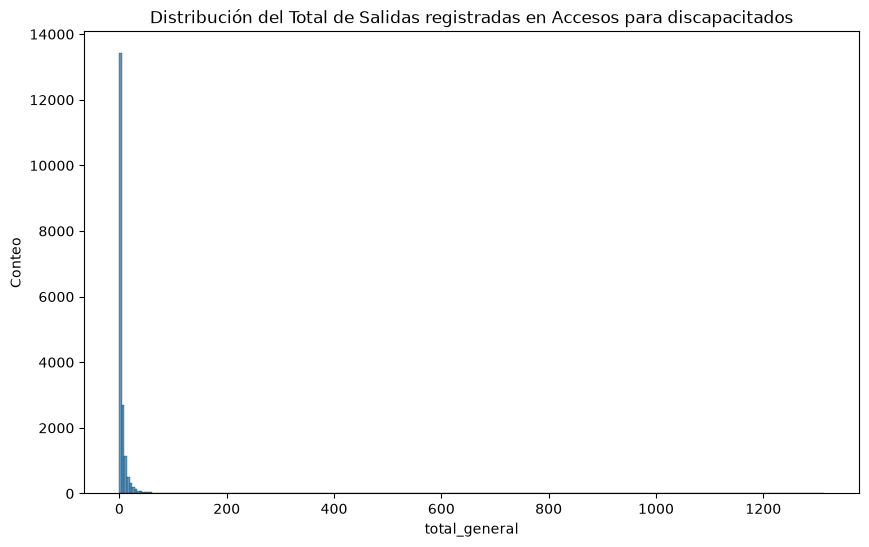

In [22]:
df_disca = df1_clean[df1_clean['Acceso_Estacion'].str.contains('discap', case=False, na=False)]

plt.figure(figsize=(10, 6))
sns.histplot(data=df_disca, x="total_general")
plt.ylabel("Conteo")
plt.title("Distribución del Total de Salidas registradas en Accesos para discapacitados")

df_disca.describe()

Se puede observar que los accesos para discapacitados en su mayoría no registran salidas. Esto puede afectar el comportamiento del resto de los datos al añadir demaciados conteos nulos.

Para garantizar un estudio sobre la población general de Bogotá se eliminarán todos los accesos para discapacitados.

In [23]:
df1_clean = df1_clean[~df1_clean['Acceso_Estacion'].str.contains('discap', case=False, na=False)]
df1_clean['Acceso_Estacion'].unique()

<StringArray>
['(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO/VILLEMAR/CALIHAYUELOS/LAESTANCIA/ZONA FRANCA/BELÉN-TC6',
       '(02) PLAT1 ALIM-ENGATIVÁ/LAFAENA/TIERRAGRATA/AEROPUERTO/ELMUELLE/AV.ELDORADO ALAMOS/VILLAAMALIA',
                                                                         '(03) Acceso Peatonal Oriental',
                                                                       '(04) Acceso Peatonal Occidental',
                                                                               '(20) Acceso Bicicletero',
                                                                  '(21) Acceso Túnel PLAT1 Alimentación',
                                                                  '(23) Acceso Túnel PLAT2 Alimentación',
                                                                         '(01) Acceso Peatonal Oriental',
                                                                       '(01) Acceso Peatonal Occidental',
                                

## - Estaciones no requeridas
Después de revisar cambios en las estaciones como cierres o reemplazos se deben hacer modificaciones en el dataframe:

- Calle 19 fue cerrada en mayo del 2025, se debe borrar
- Salitre el Greco y Salitre el Greco Vive Claro corresponden a la misma estación
- Corferias y Recinto Ferial corresponden a la misma estación
- Calle 34 y Temporal Calle 34 corresponden a la misma estación
- Las estaciones correspondientes a la linea troncal "(40)Zona T Ciudad Bolívar" corresponden a estaciones del TransMiCable, por lo que no son relevantes para el estudio
- La linea troncal Line for Intermedium Gate solo posee una estación intermedia para el portal del sur, se puede incluir en la linea troncal (30)Zona G NQS Sur

### Calle 19
Se inicia borrando la estación Calle 19, esto de paso nos libra de los datos nulos

In [24]:
df1c = df1_clean[df1_clean['Acceso_Estacion'].notnull()]
df1c.reset_index()

,index,Linea,Estacion,Acceso_Estacion,Intervalo,_2025_06_01,_2025_06_02,_2025_06_03,_2025_06_04,_2025_06_05,...,_2025_06_22,_2025_06_23,_2025_06_24,_2025_06_25,_2025_06_26,_2025_06_27,_2025_06_28,_2025_06_29,_2025_06_30,total_general
0,0,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,04:00:00,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,04:15:00,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,04:30:00,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,04:45:00,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
4,4,(11)Zona K Calle 26,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,(01) PLAT2 ALIM-DESAL FONTIBÓN/FONTIBÓN CENTRO...,05:00:00,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24561,43658,(40)Zona T Ciudad Bolívar,(40004)Bicicletero Mirador del Paraíso,(01) Acceso Bicicletero,22:00:00,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
24562,43659,(40)Zona T Ciudad Bolívar,(40004)Bicicletero Mirador del Paraíso,(01) Acceso Bicicletero,22:15:00,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
24563,43660,(40)Zona T Ciudad Bolívar,(40004)Bicicletero Mirador del Paraíso,(01) Acceso Bicicletero,22:30:00,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
24564,43661,(40)Zona T Ciudad Bolívar,(40004)Bicicletero Mirador del Paraíso,(01) Acceso Bicicletero,22:45:00,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
df1c.info()

<class 'pandas.DataFrame'>
Index: 24566 entries, 0 to 43662
Data columns (total 35 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Linea            24566 non-null  str  
 1   Estacion         24566 non-null  str  
 2   Acceso_Estacion  24566 non-null  str  
 3   Intervalo        24566 non-null  str  
 4   _2025_06_01      24566 non-null  int64
 5   _2025_06_02      24566 non-null  int64
 6   _2025_06_03      24566 non-null  int64
 7   _2025_06_04      24566 non-null  int64
 8   _2025_06_05      24566 non-null  int64
 9   _2025_06_06      24566 non-null  int64
 10  _2025_06_07      24566 non-null  int64
 11  _2025_06_08      24566 non-null  int64
 12  _2025_06_09      24566 non-null  int64
 13  _2025_06_10      24566 non-null  int64
 14  _2025_06_11      24566 non-null  int64
 15  _2025_06_12      24566 non-null  int64
 16  _2025_06_13      24566 non-null  int64
 17  _2025_06_14      24566 non-null  int64
 18  _2025_06_15      24566

### Salitre el Greco
hay que unir las estaciones Salitre el Greco y Salitre el Greco - Vive Claro, corresponden a la misma estación. Se registran entradas cuando en la otra no y viceversa, además poseen el mismo código

In [26]:
df1c[df1c['Estacion'] == '(06102)Salitre El Greco'].head()

,Linea,Estacion,Acceso_Estacion,Intervalo,_2025_06_01,_2025_06_02,_2025_06_03,_2025_06_04,_2025_06_05,_2025_06_06,...,_2025_06_22,_2025_06_23,_2025_06_24,_2025_06_25,_2025_06_26,_2025_06_27,_2025_06_28,_2025_06_29,_2025_06_30,total_general
1463,(11)Zona K Calle 26,(06102)Salitre El Greco,(01) Acceso Peatonal Oriental,04:00:00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1464,(11)Zona K Calle 26,(06102)Salitre El Greco,(01) Acceso Peatonal Oriental,04:15:00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1465,(11)Zona K Calle 26,(06102)Salitre El Greco,(01) Acceso Peatonal Oriental,04:30:00,0,0,2,0,1,0,...,1,0,0,0,0,0,0,0,0,0
1466,(11)Zona K Calle 26,(06102)Salitre El Greco,(01) Acceso Peatonal Oriental,04:45:00,1,4,5,7,12,4,...,3,0,0,0,0,0,0,0,0,0
1467,(11)Zona K Calle 26,(06102)Salitre El Greco,(01) Acceso Peatonal Oriental,05:00:00,11,2,21,18,20,18,...,2,0,0,0,0,0,0,0,0,0


In [27]:
df1c[df1c['Estacion'] == '(06102)Salitre El Greco - Vive Claro'].head()

,Linea,Estacion,Acceso_Estacion,Intervalo,_2025_06_01,_2025_06_02,_2025_06_03,_2025_06_04,_2025_06_05,_2025_06_06,...,_2025_06_22,_2025_06_23,_2025_06_24,_2025_06_25,_2025_06_26,_2025_06_27,_2025_06_28,_2025_06_29,_2025_06_30,total_general
1617,(11)Zona K Calle 26,(06102)Salitre El Greco - Vive Claro,(01) Acceso Peatonal Oriental,04:00:00,0,0,0,0,0,0,...,0,0,2,0,0,0,0,0,0,0
1618,(11)Zona K Calle 26,(06102)Salitre El Greco - Vive Claro,(01) Acceso Peatonal Oriental,04:15:00,0,0,0,0,0,0,...,0,2,0,0,1,0,2,0,0,0
1619,(11)Zona K Calle 26,(06102)Salitre El Greco - Vive Claro,(01) Acceso Peatonal Oriental,04:30:00,0,0,0,0,0,0,...,0,1,1,1,5,1,0,6,1,0
1620,(11)Zona K Calle 26,(06102)Salitre El Greco - Vive Claro,(01) Acceso Peatonal Oriental,04:45:00,0,0,0,0,0,0,...,0,5,2,7,5,6,4,6,2,0
1621,(11)Zona K Calle 26,(06102)Salitre El Greco - Vive Claro,(01) Acceso Peatonal Oriental,05:00:00,0,0,0,0,0,0,...,0,2,8,14,9,11,13,13,7,0


In [28]:
# Poner todas las estaciones del mismo nombre
df1c['Estacion'] = df1c['Estacion'].replace(
    '(06102)Salitre El Greco', 
    '(06102)Salitre El Greco - Vive Claro'
)

# Agrupar especificando todas las columnas para evitar perder el orden del dataframe
# as_index=False mantiene las columnas agrupadas como columnas normales
df1c = df1c.groupby(
    ['Linea', 'Estacion', 'Acceso_Estacion', 'Intervalo'], 
    as_index=False
).sum(numeric_only=True)

df1c[df1c['Estacion'] == '(06102)Salitre El Greco - Vive Claro'].head()

,Linea,Estacion,Acceso_Estacion,Intervalo,_2025_06_01,_2025_06_02,_2025_06_03,_2025_06_04,_2025_06_05,_2025_06_06,...,_2025_06_22,_2025_06_23,_2025_06_24,_2025_06_25,_2025_06_26,_2025_06_27,_2025_06_28,_2025_06_29,_2025_06_30,total_general
847,(11)Zona K Calle 26,(06102)Salitre El Greco - Vive Claro,(01) Acceso Peatonal Oriental,04:00:00,0,0,0,0,0,0,...,0,0,2,0,0,0,0,0,0,0
848,(11)Zona K Calle 26,(06102)Salitre El Greco - Vive Claro,(01) Acceso Peatonal Oriental,04:15:00,0,0,0,0,0,0,...,0,2,0,0,1,0,2,0,0,0
849,(11)Zona K Calle 26,(06102)Salitre El Greco - Vive Claro,(01) Acceso Peatonal Oriental,04:30:00,0,0,2,0,1,0,...,1,1,1,1,5,1,0,6,1,0
850,(11)Zona K Calle 26,(06102)Salitre El Greco - Vive Claro,(01) Acceso Peatonal Oriental,04:45:00,1,4,5,7,12,4,...,3,5,2,7,5,6,4,6,2,0
851,(11)Zona K Calle 26,(06102)Salitre El Greco - Vive Claro,(01) Acceso Peatonal Oriental,05:00:00,11,2,21,18,20,18,...,2,2,8,14,9,11,13,13,7,0


### Corferias
Las estaciones corferias y recinto ferial tienen el mismo problema que salitre el greco

In [29]:
df1c['Estacion'] = df1c['Estacion'].replace(
    '(06106)Recinto Ferial', 
    '(06106)Corferias'
)

df1c = df1c.groupby(
    ['Linea', 'Estacion', 'Acceso_Estacion', 'Intervalo'], 
    as_index=False
).sum(numeric_only=True)

df1c[df1c['Estacion'] == '(06106)Corferias'].head()

,Linea,Estacion,Acceso_Estacion,Intervalo,_2025_06_01,_2025_06_02,_2025_06_03,_2025_06_04,_2025_06_05,_2025_06_06,...,_2025_06_22,_2025_06_23,_2025_06_24,_2025_06_25,_2025_06_26,_2025_06_27,_2025_06_28,_2025_06_29,_2025_06_30,total_general
1155,(11)Zona K Calle 26,(06106)Corferias,(01) Acceso Peatonal Oriental,04:00:00,2,0,0,0,3,1,...,1,0,0,0,1,2,0,0,1,0
1156,(11)Zona K Calle 26,(06106)Corferias,(01) Acceso Peatonal Oriental,04:15:00,0,2,0,0,0,1,...,0,0,0,0,0,0,0,0,2,0
1157,(11)Zona K Calle 26,(06106)Corferias,(01) Acceso Peatonal Oriental,04:30:00,11,5,0,1,0,0,...,1,0,0,2,0,1,2,0,2,0
1158,(11)Zona K Calle 26,(06106)Corferias,(01) Acceso Peatonal Oriental,04:45:00,29,26,12,8,6,8,...,2,2,5,9,8,1,5,0,1,0
1159,(11)Zona K Calle 26,(06106)Corferias,(01) Acceso Peatonal Oriental,05:00:00,22,20,22,22,21,25,...,7,11,16,16,20,18,20,8,6,0


### Calle 34
De igual forma para esta estación

In [30]:
df1c['Estacion'] = df1c['Estacion'].replace(
    '(09115)Calle 34 - Fondo Nacional de Garantias', 
    '(09124)Temporal Calle 34 - Fondo Nacional de Garantias'
)

df1c = df1c.groupby(
    ['Linea', 'Estacion', 'Acceso_Estacion', 'Intervalo'], 
    as_index=False
).sum(numeric_only=True)

df1c[df1c['Estacion'] == '(09124)Temporal Calle 34 - Fondo Nacional de Garantias'].tail()

,Linea,Estacion,Acceso_Estacion,Intervalo,_2025_06_01,_2025_06_02,_2025_06_03,_2025_06_04,_2025_06_05,_2025_06_06,...,_2025_06_22,_2025_06_23,_2025_06_24,_2025_06_25,_2025_06_26,_2025_06_27,_2025_06_28,_2025_06_29,_2025_06_30,total_general
21943,(36)Zona A Caracas,(09124)Temporal Calle 34 - Fondo Nacional de G...,(BA) Acceso Sur,22:00:00,2,12,33,25,27,25,...,0,0,0,0,0,0,0,0,0,0
21944,(36)Zona A Caracas,(09124)Temporal Calle 34 - Fondo Nacional de G...,(BA) Acceso Sur,22:15:00,15,9,32,22,33,14,...,0,0,0,0,0,0,0,0,0,0
21945,(36)Zona A Caracas,(09124)Temporal Calle 34 - Fondo Nacional de G...,(BA) Acceso Sur,22:30:00,2,5,11,17,25,16,...,0,0,0,0,0,0,0,0,0,0
21946,(36)Zona A Caracas,(09124)Temporal Calle 34 - Fondo Nacional de G...,(BA) Acceso Sur,22:45:00,4,3,13,11,14,13,...,0,0,0,0,0,0,0,0,0,0
21947,(36)Zona A Caracas,(09124)Temporal Calle 34 - Fondo Nacional de G...,(BA) Acceso Sur,23:00:00,4,3,6,10,5,14,...,0,0,0,0,0,0,0,0,0,0


### Zona T Ciudad Bolivar
Simplemente se eliminarán estas estaciones, pues el estudio se centra en el servicio de buses troncales

In [31]:
df1c = df1c[df1c['Linea'] != '(40)Zona T Ciudad Bolívar']
df1c[df1c['Linea'] == '(40)Zona T Ciudad Bolívar']

,Linea,Estacion,Acceso_Estacion,Intervalo,_2025_06_01,_2025_06_02,_2025_06_03,_2025_06_04,_2025_06_05,_2025_06_06,...,_2025_06_22,_2025_06_23,_2025_06_24,_2025_06_25,_2025_06_26,_2025_06_27,_2025_06_28,_2025_06_29,_2025_06_30,total_general


### Line for intermedium gate
simplemente se reemplazará el nombre de la linea troncal para incluirlo en Zona G NQS Sur

In [32]:
df1c['Linea'].unique()

<StringArray>
[          '(11)Zona K Calle 26',         '(12)Zona L Carrera 10',
 '(21)Line for Intermedium Gate',            '(30)Zona G NQS Sur',
       '(31)Zona F Av. Américas',           '(32)Zona C Av. Suba',
          '(33)Zona B AutoNorte',        '(34)Zona H Caracas Sur',
           '(35)Zona D Calle 80',            '(36)Zona A Caracas',
      '(37)Zona J Eje Ambiental',        '(38)Zona E NQS Central']
Length: 12, dtype: str

In [33]:
df1c_21 = df1c[df1c['Linea'] == '(21)Line for Intermedium Gate']
df1c_21['Estacion'].unique()

<StringArray>
['(59503) Intermedias San Mateo']
Length: 1, dtype: str

Corresponde a una estación intermedia hacia el portal del sur, por tanto se incluirá en la linea troncal G

In [34]:
df1c.loc[df1c['Linea'] == '(21)Line for Intermedium Gate', 'Linea'] = '(30)Zona G NQS Sur'
df1c.reset_index()
df1c['Linea'].unique()

<StringArray>
[     '(11)Zona K Calle 26',    '(12)Zona L Carrera 10',
       '(30)Zona G NQS Sur',  '(31)Zona F Av. Américas',
      '(32)Zona C Av. Suba',     '(33)Zona B AutoNorte',
   '(34)Zona H Caracas Sur',      '(35)Zona D Calle 80',
       '(36)Zona A Caracas', '(37)Zona J Eje Ambiental',
   '(38)Zona E NQS Central']
Length: 11, dtype: str

### Error en total_general

revisando el dataframe se encontro que habían registros en los que total_general no sumaba correctamente las salidas, esto se pudo observar en calle 34 y portal suba. Para asegurarse de que no hayan problemas similares, incluso con los cambios realizados, se reescribirá la columna realizando las sumas manualmente.

In [35]:
df1c[(df1c['Estacion'] == '(03000)Portal Suba') &
    (df1c['Acceso_Estacion'] == '(28) Desalimentación La Gaitana/Lisboa')
].tail()

,Linea,Estacion,Acceso_Estacion,Intervalo,_2025_06_01,_2025_06_02,_2025_06_03,_2025_06_04,_2025_06_05,_2025_06_06,...,_2025_06_22,_2025_06_23,_2025_06_24,_2025_06_25,_2025_06_26,_2025_06_27,_2025_06_28,_2025_06_29,_2025_06_30,total_general
10852,(32)Zona C Av. Suba,(03000)Portal Suba,(28) Desalimentación La Gaitana/Lisboa,22:00:00,0,0,0,0,0,0,...,135,129,138,169,160,195,148,183,113,0
10853,(32)Zona C Av. Suba,(03000)Portal Suba,(28) Desalimentación La Gaitana/Lisboa,22:15:00,0,0,0,0,0,0,...,73,94,153,175,164,205,120,105,111,0
10854,(32)Zona C Av. Suba,(03000)Portal Suba,(28) Desalimentación La Gaitana/Lisboa,22:30:00,0,0,0,0,0,0,...,90,66,95,159,113,244,164,155,133,0
10855,(32)Zona C Av. Suba,(03000)Portal Suba,(28) Desalimentación La Gaitana/Lisboa,22:45:00,0,0,0,0,2,0,...,47,109,251,133,232,116,97,87,47,0
10856,(32)Zona C Av. Suba,(03000)Portal Suba,(28) Desalimentación La Gaitana/Lisboa,23:00:00,0,0,0,0,0,0,...,36,105,131,91,219,186,114,82,95,0


In [36]:
#borrar la columna de total_general
df1c = df1c.drop('total_general', axis=1)

#crear una columna con las sumas
df1c['total_general'] = df1c.iloc[:, 4:34].sum(axis=1)
df1c[(df1c['Estacion'] == '(03000)Portal Suba') &
    (df1c['Acceso_Estacion'] == '(28) Desalimentación La Gaitana/Lisboa')
].tail()

,Linea,Estacion,Acceso_Estacion,Intervalo,_2025_06_01,_2025_06_02,_2025_06_03,_2025_06_04,_2025_06_05,_2025_06_06,...,_2025_06_22,_2025_06_23,_2025_06_24,_2025_06_25,_2025_06_26,_2025_06_27,_2025_06_28,_2025_06_29,_2025_06_30,total_general
10852,(32)Zona C Av. Suba,(03000)Portal Suba,(28) Desalimentación La Gaitana/Lisboa,22:00:00,0,0,0,0,0,0,...,135,129,138,169,160,195,148,183,113,3088
10853,(32)Zona C Av. Suba,(03000)Portal Suba,(28) Desalimentación La Gaitana/Lisboa,22:15:00,0,0,0,0,0,0,...,73,94,153,175,164,205,120,105,111,3158
10854,(32)Zona C Av. Suba,(03000)Portal Suba,(28) Desalimentación La Gaitana/Lisboa,22:30:00,0,0,0,0,0,0,...,90,66,95,159,113,244,164,155,133,3311
10855,(32)Zona C Av. Suba,(03000)Portal Suba,(28) Desalimentación La Gaitana/Lisboa,22:45:00,0,0,0,0,2,0,...,47,109,251,133,232,116,97,87,47,2878
10856,(32)Zona C Av. Suba,(03000)Portal Suba,(28) Desalimentación La Gaitana/Lisboa,23:00:00,0,0,0,0,0,0,...,36,105,131,91,219,186,114,82,95,2977


Realizados todos estos cambios se puede observar principalmente un cambio en el primer cuartil de los datos. Aun hay muchos outliers, pero esto ya se debe al comportamiento intrinseco de los datos, relacionado con las marcadas horas pico de Bogotá.

,_2025_06_01,_2025_06_02,_2025_06_03,_2025_06_04,_2025_06_05,_2025_06_06,_2025_06_07,_2025_06_08,_2025_06_09,_2025_06_10,...,_2025_06_22,_2025_06_23,_2025_06_24,_2025_06_25,_2025_06_26,_2025_06_27,_2025_06_28,_2025_06_29,_2025_06_30,total_general
count,23950.000000,23950.000000,23950.000000,23950.000000,23950.000000,23950.00000,23950.000000,23950.000000,23950.000000,23950.000000,...,23950.000000,23950.000000,23950.000000,23950.000000,23950.000000,23950.000000,23950.000000,23950.000000,23950.000000,23950.000000
mean,35.263299,30.921461,94.928559,93.783716,93.066639,90.57833,67.075365,34.451858,88.333194,90.724843,...,35.072735,32.262380,92.391148,93.929353,90.502714,88.097662,64.274113,37.451399,31.104509,2182.638914
std,49.978768,43.470126,144.621770,142.113650,139.263662,131.48043,83.919391,50.250333,135.923488,139.657043,...,48.995159,45.266499,137.969847,137.284891,135.601974,126.413162,82.922508,56.588334,44.526393,2949.020526
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,4.000000,10.000000,10.000000,10.000000,11.00000,9.000000,4.000000,9.000000,10.000000,...,4.000000,4.000000,10.000000,11.250000,10.000000,11.000000,8.000000,4.000000,4.000000,313.000000
50%,18.000000,17.000000,46.000000,46.000000,46.000000,46.00000,38.000000,19.000000,43.000000,44.000000,...,19.000000,18.000000,47.000000,48.000000,44.000000,45.000000,35.000000,19.000000,16.000000,1208.000000
75%,46.000000,40.000000,119.000000,118.000000,117.000000,116.00000,92.000000,44.000000,109.000000,111.000000,...,45.000000,42.000000,116.000000,120.000000,114.000000,114.000000,87.000000,47.000000,40.000000,2881.000000
max,616.000000,534.000000,1728.000000,1604.000000,1741.000000,1610.00000,722.000000,826.000000,1848.000000,1662.000000,...,693.000000,554.000000,1751.000000,1590.000000,1597.000000,1446.000000,835.000000,911.000000,515.000000,31700.000000


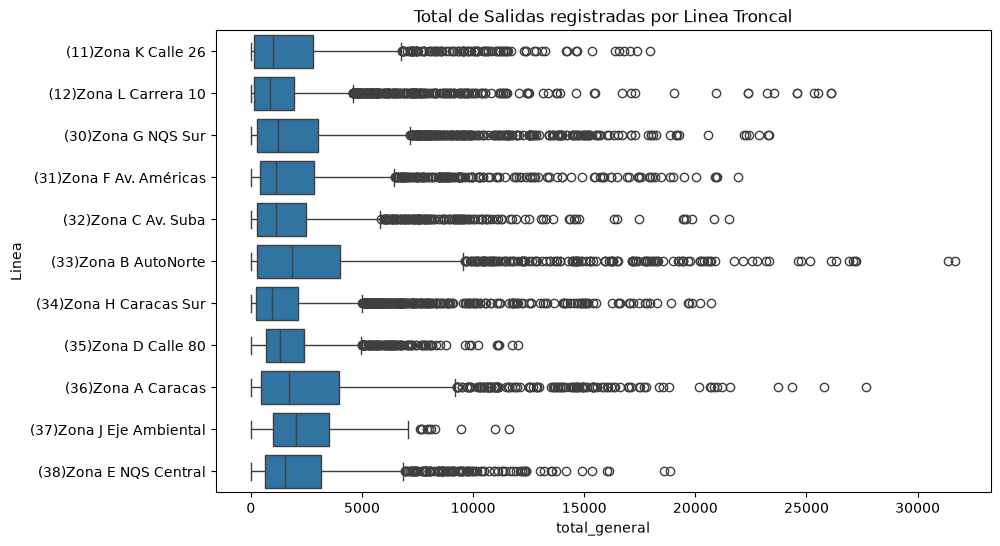

In [37]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df1c, x="total_general", y="Linea")
plt.title("Total de Salidas registradas por Linea Troncal")

df1c.describe()

# Limpieza de Datos (Registro de Estaciones)

## - Estaciones no requeridas
También es necesario realizar algunos cambios en este dataframe para eliminar estaciones que ya no estan en funcionamiento o que no habían sido implementadas en junio del 2025

- Las estaciones Tabanica, Los Laureles e Islandia fueron implementadas este mismo año, por lo que no son de interés para el estudio
- La estación Calle 146 fue cerrada en diciembre del 2024 y reabrió en diciembre del 2025, por lo que tampoco es relevante para el estudio
- SENA fue cerrada en 2023, Calle 63 y Patio Bonito en 2024, Tercer Milenio en abril del 2025 y Calle 19 en mayo del 2025
- Calle 72 fue implmementada este año como reemplazo para Calle 76
- La estación Temporal Marly entro en operación en septiembre del 2025

Todas estas estaciones pueden ser borradas

In [38]:
df2c = df2[(df2['id_trazado'] != 'TZ022') & 
            (df2['nom_est'] != 'Calle 146') &
            (df2['nom_est'] != 'SENA') &
            (df2['nom_est'] != 'Calle 63') &
            (df2['nom_est'] != 'Patio Bonito') &
            (df2['nom_est'] != 'Tercer Milenio') &
            (df2['nom_est'] != 'Calle 19') &
            (df2['nom_est'] != 'Calle 72 - Areandina') &
            (df2['nom_est'] != 'Temporal Marly')
    ]

## - Agrupación por linea troncal
Por conveniencia se pueden agrupar las estaciones por línea troncal de igual forma que en el dataframe de las empleando la columna id_trazado

In [39]:
#asignar a id_trazado la letra de la linea troncal correspondiente
linea_troncal = {
    'TZ008' : 'E', 'TZ007' : 'E',
    'TZ016' : 'K',
    'TZ018' : 'L', 'TZ019' : 'L',
    'TZ005' : 'D',
    'TZ003' : 'C',
    'TZ012' : 'H', 'TZ013' : 'H', 'TZ014' : 'H',
    'TZ009' : 'F',
    'TZ001' : 'A',
    'TZ010' : 'G', 'TZ011' : 'G',
    'TZ002' : 'B',
    'TZ015' : 'J',
}

df2c['linea_t'] = df2c['id_trazado'].map(linea_troncal)
df2c = df2c.sort_values(by=['linea_t', 'id_trazado'])
df2c.head()

,X,Y,latitud,longitud,nom_est,id_trazado,ub_est,tipo_esta,num_vag,num_acc,eta_oper,linea_t
60,1.001068e+06,1.003898e+06,4.631452,-74.067879,Calle 45 - American School Way,TZ001,CL 45 - CL 42A,4,3,2,3,A
70,9.994653e+05,1.000439e+06,4.602867,-74.080410,Temporal AV. Jiménez - Inter Eléctricas,TZ001,CL 13 - CL 11,3,3,2,1,A
76,1.001338e+06,1.005398e+06,4.642982,-74.065828,Temporal Calle 57,TZ001,CL 57 - CL 54,4,2,2,1,A
79,1.000594e+06,1.002262e+06,4.616652,-74.072158,Calle 26 - Atrio,TZ001,AV Calle 28 - CL 2,4,3,2,1,A
87,1.001803e+06,1.007390e+06,4.663029,-74.061261,Calle 76 - San Felipe,TZ001,CL 76 - CL 74,4,3,2,1,A


# Análisis

## Horas Pico
Al graficar el total general respecto a los intervalos, se puede visualizar las marcadas horas pico que posee en sistema: aproximadamente de 6:30am a 8:30am la primera y 5:15pm a 8:15pm la segunda.

Por la mañana el flujo de personas aumenta en las estaciones de destino y por la noche en las estaciones de salida

Text(0.5, 1.0, 'Salidas Totales registradas')

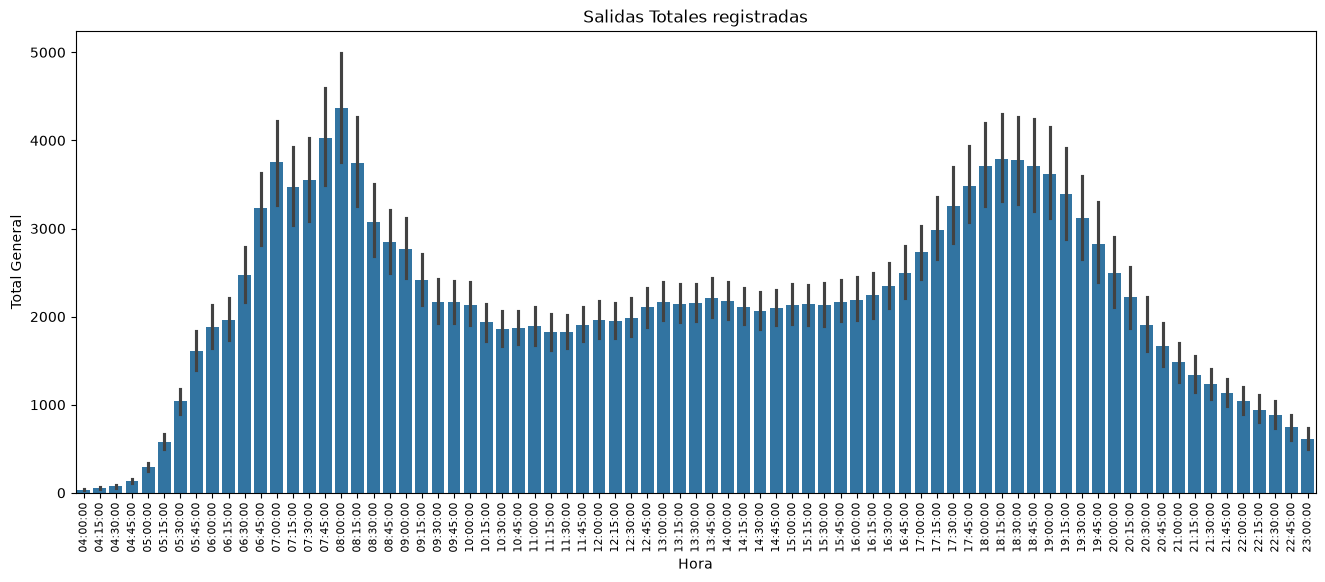

In [40]:
plt.figure(figsize=(16, 6))
sns.barplot(data=df1c, y="total_general", x='Intervalo')

plt.xticks(rotation=90, fontsize=8) 
plt.yticks(fontsize=10)

plt.ylabel("Total General")
plt.xlabel("Hora")
plt.title("Salidas Totales registradas")

Si se desea estudiar el comportamiento general del flujo de personas a lo largo del día en el sistema, se puede realizar una limpieza de outliers

In [41]:
df1_outlier = df1c.copy()

def cleaning(df1_clean, df1_outlier, column):
    # Calcular cuartiles
    Q1 = df1_clean.iloc[:, column].quantile(0.25)
    Q3 = df1_clean.iloc[:, column].quantile(0.75)
    # Rango Intercuartil
    IQR = Q3 - Q1
    # Límites
    sup_limit = Q3 + 1.5 * IQR
    inf_limit = Q1 - 1.5 * IQR
    
    # Filtrar
    df1_outlier = df1_outlier[
        (df1_outlier.iloc[:, column] >= inf_limit) &
        (df1_outlier.iloc[:, column] <= sup_limit)
    ]
    return df1_outlier

for column in range(4, 35):
    df1_outlier = cleaning(df1_clean, df1_outlier, column)

Text(0.5, 1.0, 'Salidas Totales registradas')

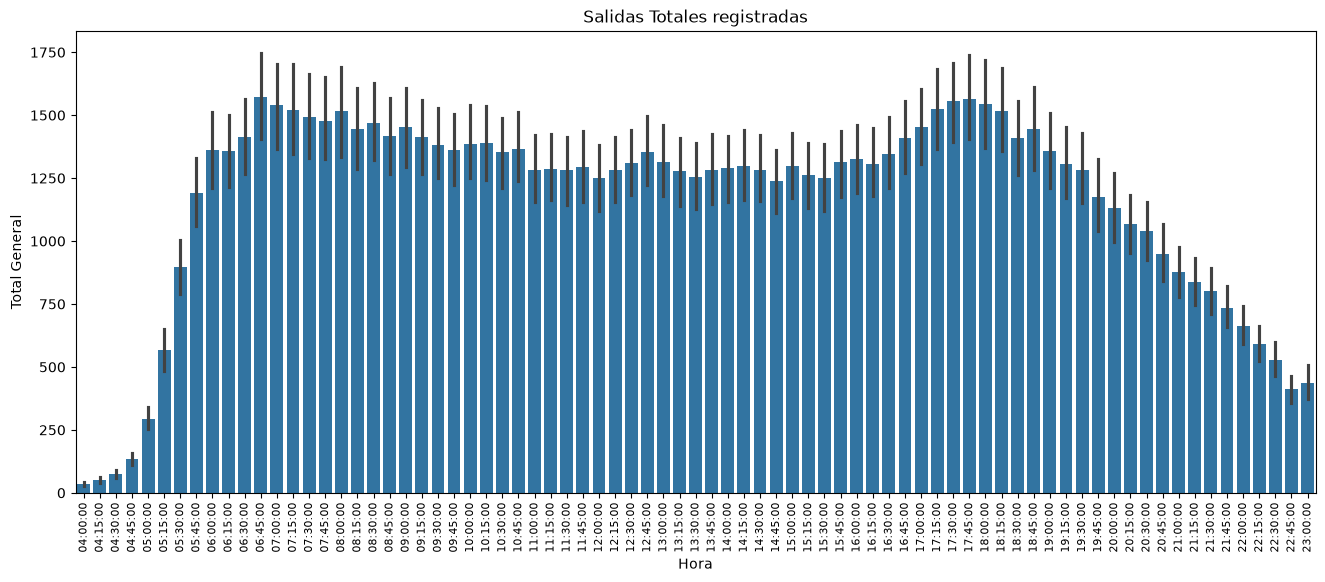

In [42]:
plt.figure(figsize=(16, 6))
sns.barplot(data=df1_outlier, y="total_general", x='Intervalo')

plt.xticks(rotation=90, fontsize=8) 
plt.yticks(fontsize=10)

plt.ylabel("Total General")
plt.xlabel("Hora")
plt.title("Salidas Totales registradas")

In [43]:
df1_outlier['total_general'].mean()

np.float64(1133.6356653518787)

Realizada la limpieza se puede observar que se tiene un flujo aproximadamente constante con un promedio de salidas registradas de 288.

Sin embargo se considera que realizar esta limpieza modifica demasiado el comportamiento real del sistema a lo largo del día, por lo que no resulta conveniente para el estudio.

## Zonas de mayor flujo
Realizando un mapa de calor diferenciando entre lineas troncales podemos observar cuales registran un mayor número de salidas

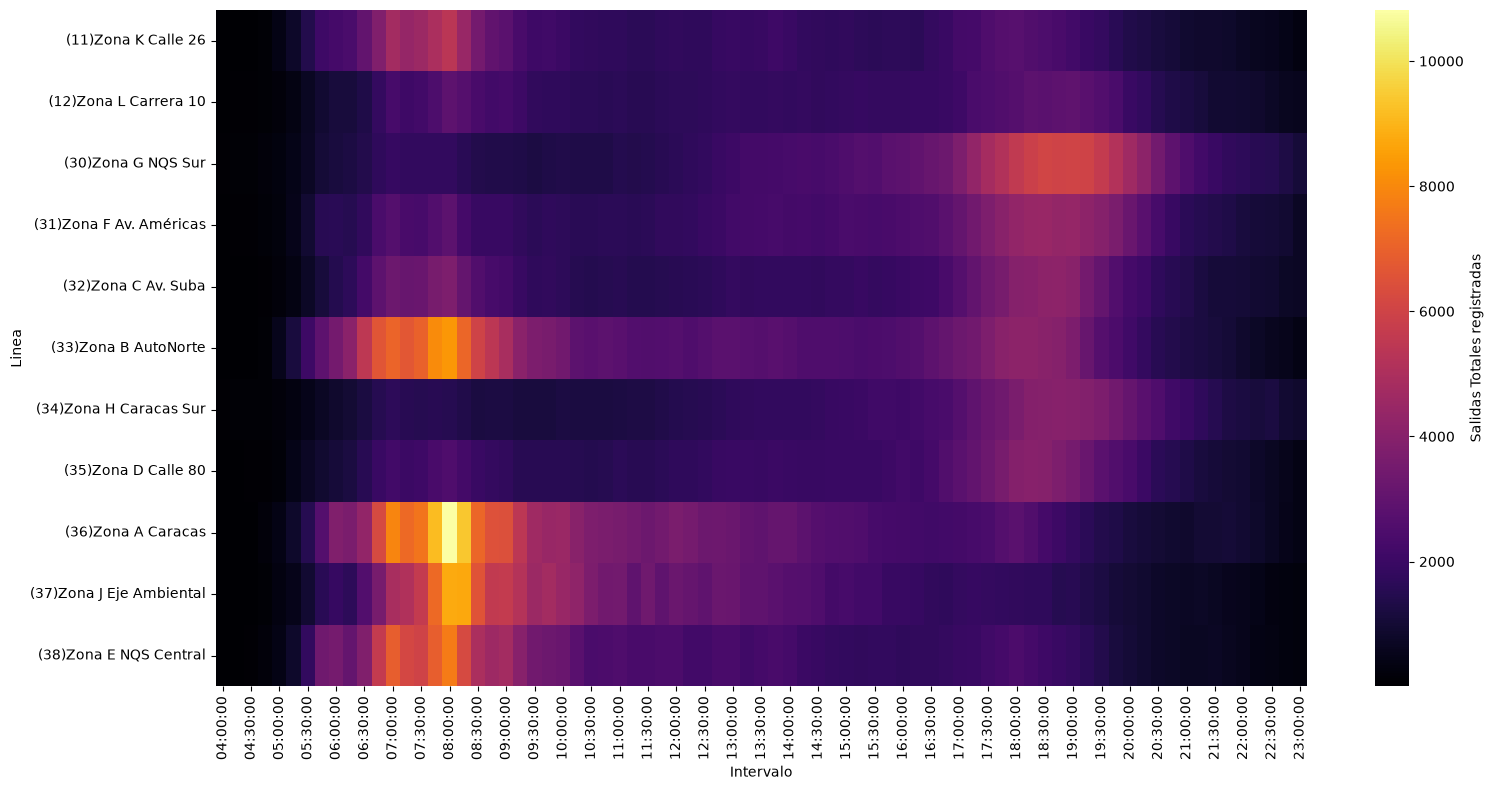

In [44]:
heatmap_data = df1c.pivot_table(
    index="Linea",       # Eje Y
    columns="Intervalo",    # Eje X
    values="total_general", # El color/valor
)

plt.figure(figsize=(16, 8))

sns.heatmap(
    heatmap_data, 
    cmap="inferno", 
    cbar_kws={"label": "Salidas Totales registradas"}
)

# 4. Ajustar el tamaño y rotación de las letras para que se lean bien
plt.xticks(rotation=90, fontsize=10) 
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

### - Estaciones de destino
Se puede observar que en la hora pico de la mañana las lineas troncales A Caracas, J Eje ambiental y B AutoNorte son las que más registran salidas, lo que resulta lógico al ser las principales zonas laborales y universitarias de Bogotá.

Text(0.5, 1.0, 'Flujo en A Caracas')

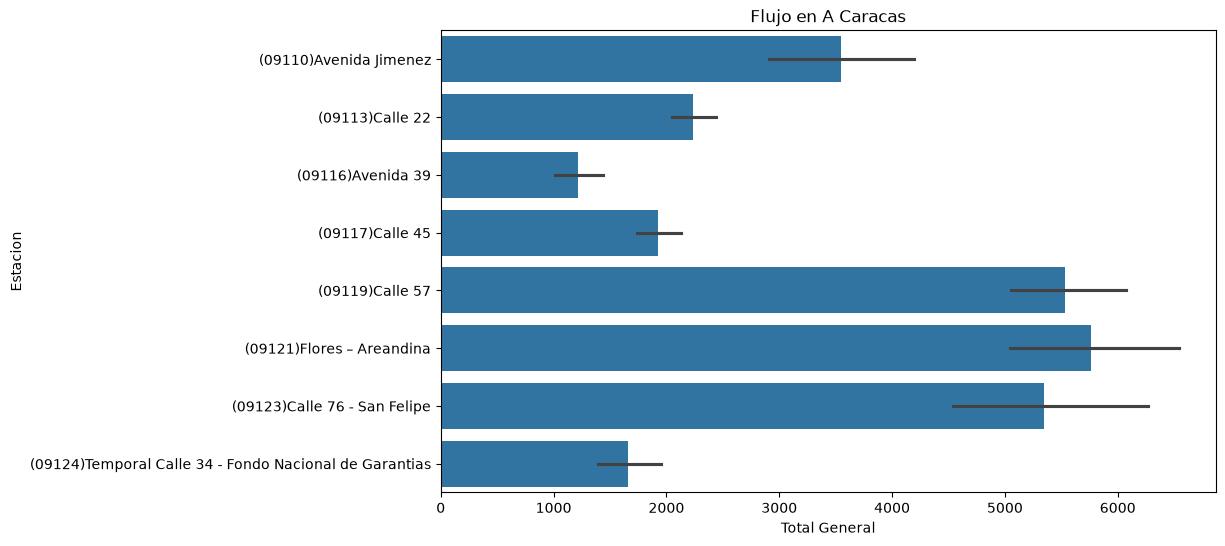

In [45]:
plt.figure(figsize=(10, 6))

sns.barplot(data=df1c[df1c['Linea'] == '(36)Zona A Caracas'], y="Estacion", x="total_general")

plt.xlabel("Total General")
plt.title("Flujo en A Caracas")

Text(0.5, 1.0, 'Flujo en J Eje Ambiental')

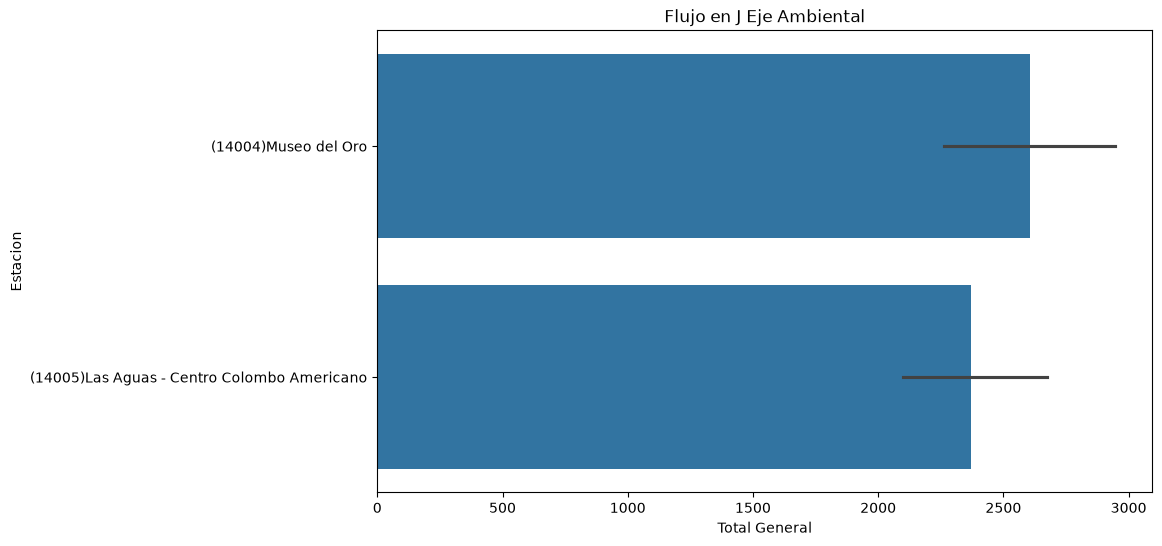

In [46]:
plt.figure(figsize=(10, 6))

sns.barplot(data=df1c[df1c['Linea'] == '(37)Zona J Eje Ambiental'], y="Estacion", x="total_general")

plt.xlabel("Total General")
plt.title("Flujo en J Eje Ambiental")

Text(0.5, 1.0, 'Flujo en B AutoNorte')

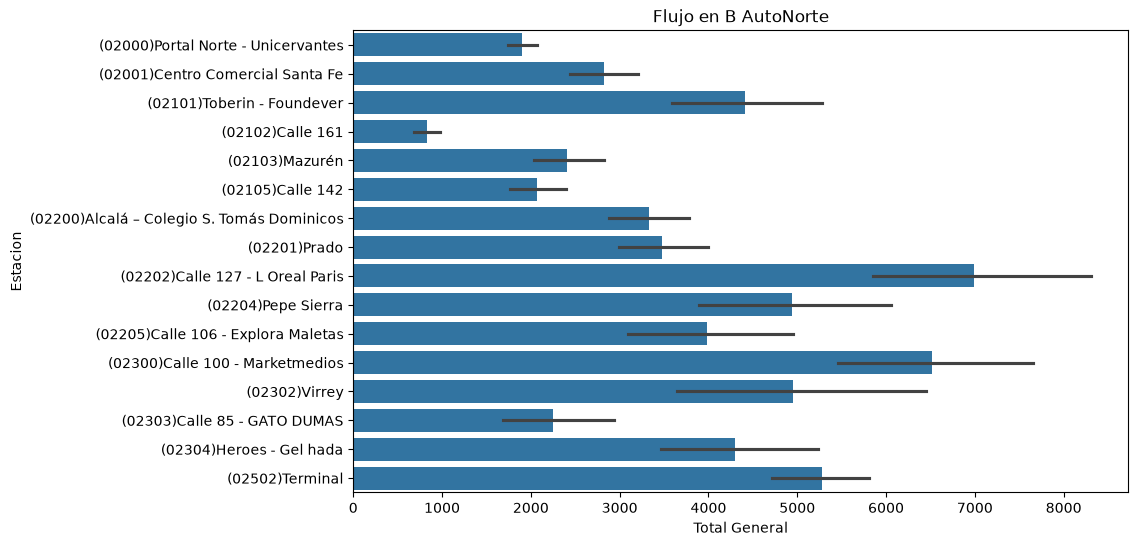

In [47]:
plt.figure(figsize=(10, 6))

sns.barplot(data=df1c[df1c['Linea'] == '(33)Zona B AutoNorte'], y="Estacion", x="total_general")

plt.xlabel("Total General")
plt.title("Flujo en B AutoNorte")

En las lineas troncales de mayor flujo, las estaciones que más registran salidas son:

- A Caracas: Flores - Areandina
- J Eje Ambiental: Museo del Oro
- B AutoNorte: Calle 127 - L Oreal Paris


### - Estaciones de llegada

Observando en la misma gráfica del mapa de calor, se puede ver que la linea troncal que más registra salidas en la hora pico nocturna es la G NQS Sur

Text(0.5, 1.0, 'Flujo en G NQS Sur')

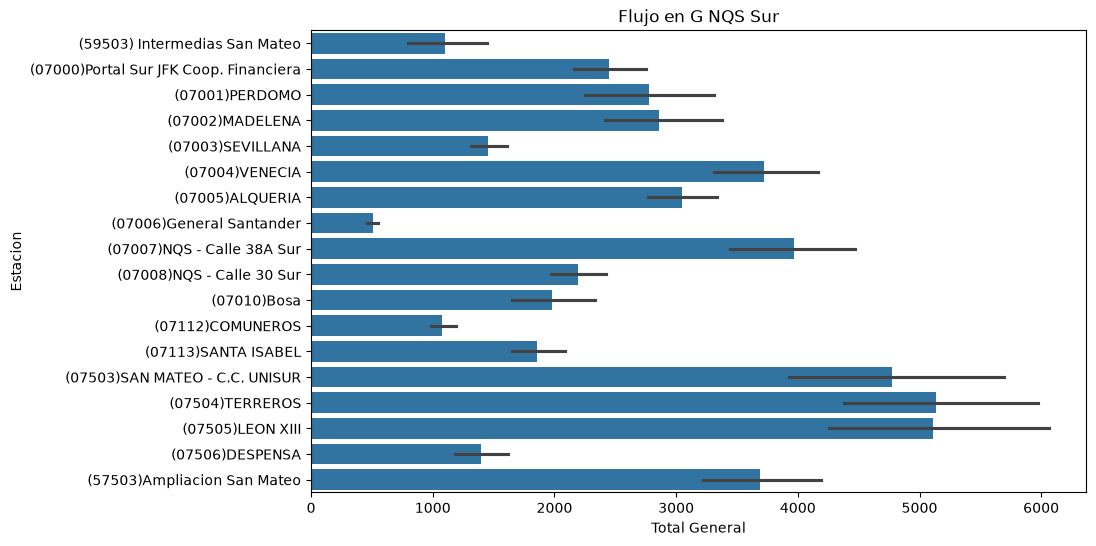

In [48]:
plt.figure(figsize=(10, 6))

sns.barplot(data=df1c[df1c['Linea'] == '(30)Zona G NQS Sur'], y="Estacion", x="total_general")

plt.xlabel("Total General")
plt.title("Flujo en G NQS Sur")

La estación con mayor registro de salidas es la estación San Mateo - CC Unisur, que como es de esperarse es la estación de inicio de la linea troncal.

El mayor número de salidas de la hora pico nocturna se registran en las estaciones de inicio cuanto la gente regresa a sus casas. Por lo que es la hora que hay que observar para hallar la zona de la ciudad con mayor uso del sistema de Transmilenio.

También se puede obtener el total de salidas para cada estación y ver en general cuales registran un mayor número

In [49]:
estaciones = df1c[['Estacion', 'total_general']]

#sumar el total de las estaciones
estaciones = estaciones.groupby(
    'Estacion', 
    as_index=False
).sum(numeric_only=True)

#organizar de mayor a menor
estaciones = estaciones.sort_values(by="total_general", ascending=False)

estaciones.head(17)

,Estacion,total_general
0,(02000)Portal Norte - Unicervantes,1903487
44,(05000)Portal Américas,1804714
67,(07000)Portal Sur JFK Coop. Financiera,1697529
16,(03000)Portal Suba,1647767
30,(04000)Cabecera Calle 80,1494937
53,(06000)Portal El Dorado - C.C. NUESTRO BOGOTA,1417965
99,(09000)Cabecera Usme,1343215
96,(08000)Portal Tunal,1321649
121,(10000)Portal 20 de Julio,1236711
47,(05100)Banderas P. Central,1034801


In [50]:
estaciones.describe()

,total_general
count,1.460000e+02
mean,3.580425e+05
std,3.672944e+05
min,0.000000e+00
25%,1.466540e+05
50%,2.331070e+05
75%,3.906245e+05
max,1.903487e+06


In [51]:
estaciones.tail(3)

,Estacion,total_general
20,(03004)GRATAMIRA,29291
143,(50008)Corral Portal Dorado,8856
141,(50002)Corral Calle 40 Sur,0


Hay una estación que no registró salidas, puede ser borrada

In [52]:
df1c = df1c[df1c['Estacion'] != '(50002)Corral Calle 40 Sur']
estaciones = estaciones[estaciones['Estacion'] != '(50002)Corral Calle 40 Sur']

estaciones.describe().T

,count,mean,std,min,25%,50%,75%,max
total_general,145.0,360511.737931,367349.51409,8856.0,149180.0,233211.0,393560.0,1903487.0


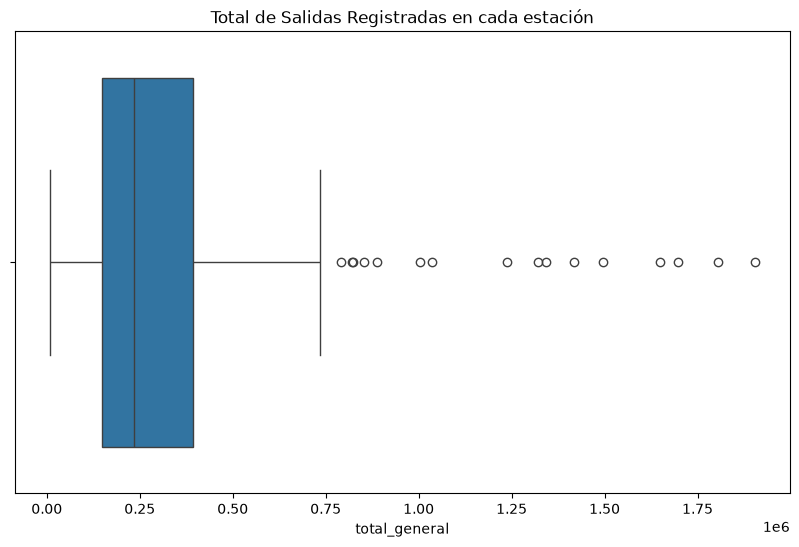

In [53]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=estaciones, x="total_general")
plt.title("Total de Salidas Registradas en cada estación")
plt.show()

Naturalmente se registran algunos outliers, correspondientes a los portales, estaciones intermedias y algunas estaciones de destino que deben recibir a todas las personas de una zona grande de la ciudad.

### - Comparación con el tamaño de las estaciones

Empleando el segundo dataframe se pueden observar cuales son las estaciones más grandes en cuanto a número de vagones.

En este caso se muestran las estaciones con 3 vagones o más.

In [54]:
#estaciones con 3 vagones o más
df_vagones = df2c[df2c["num_vag"]>=3]

#estaciones halladas anteriormente
df_comparacion = df2c[
    (df2c['nom_est'] == 'Temporal Flores – Areandina') |
    (df2c['nom_est'] == 'Banderas') |
    (df2c['nom_est'] == 'Calle 100 - Marketmedios') |
    (df2c['nom_est'] == 'Temporal Calle 57') |
    (df2c['nom_est'] == 'Calle 76 - San Felipe') |
    (df2c['nom_est'] == 'Temporal AV. Jiménez - Inter Eléctricas')
]

#geodataframes, uno para todas las estaciones y otro para las estaciones grandes
gdf = gpd.GeoDataFrame(
    df2c,
    geometry = gpd.points_from_xy(
        df2c["longitud"],
        df2c["latitud"]
    ),
    crs = "EPSG:4326"
)

gdf_vagones = gpd.GeoDataFrame(
    df_vagones,
    geometry = gpd.points_from_xy(
        df_vagones["longitud"],
        df_vagones["latitud"]
    ),
    crs = "EPSG:4326"
)

gdf_comparacion = gpd.GeoDataFrame(
    df_comparacion,
    geometry = gpd.points_from_xy(
        df_comparacion["longitud"],
        df_comparacion["latitud"]
    ),
    crs = "EPSG:4326"
)

In [55]:
import folium
from folium.features import DivIcon

# Muestra un mapa interactivo con OpenStreetMap de fondo
map = gdf.explore(
    column="linea_t",       # indicar que columna define los grupos
    cmap="tab20b",             # Paleta especial con 20 colores distintos
    categorical=True,          # Obliga a tratar los IDs como grupos separados (no como un degradado)
    legend=True,
    marker_kwds={"radius": 3},
    tooltip=["nom_est", "linea_t"],
    name="Estaciones"
)

gdf_vagones.explore(
    m = map,                   # Coloca los puntos en el mismo mapa "map"
    color="blue",               
    marker_kwds={"radius": 6},
    tooltip=["nom_est", "num_vag"],
    name="Estaciones Grandes (>=3 vagones)"
)

gdf_comparacion.explore(
    m = map,
    color="red",               
    marker_kwds={"radius": 4},
    tooltip=["nom_est", "num_vag"],
    name="Estaciones de troncales con más salidas",
)

#Crea la leyenda
folium.LayerControl().add_to(map)
map

Se puede observar que para las 6 estaciones con mayor flujo de personas (exeptuando portales) el número de vagones coincide con la demanda.

Sin embargo hay algunas excepciones, entre ellas la estacion Flores - Areandina de la linea troncal A Caracas que como vimos anteriormente es la que más salidas reporta para la hora pico de la mañana.

Se infiere que las entradas a la estación tienen un comportamiento similar en la hora pico nocturna. Esto puede indicar que la estación no puede soportar la demanda ciudadana, teniendo mucho aforo y obligando a las personas a realizar trasbordos.

Este comportamiento es similiar para la estación Museo del Oro, que posee un único vagon.

## Afectaciones de la primera linea del Metro

Empleando la serie eta_oper se pueden conocer que estaciones estan cerradas por obras y rastrear su relación con la línea del metro

In [56]:
df_oper = df2[df2["eta_oper"]>1] #estaciones que no esten operando con regularidad

gdf_oper = gpd.GeoDataFrame(
    df_oper,
    geometry = gpd.points_from_xy(
        df_oper["longitud"],
        df_oper["latitud"]
    ),
    crs = "EPSG:4326"
)


map = gdf.explore(
    column="linea_t",      
    cmap="tab20b",           
    categorical=True,          
    legend=True,
    marker_kwds={"radius": 3},
    tooltip=["nom_est", "linea_t"],
    name="Estaciones"
)

gdf_oper.explore(
    m = map,                   
    color="red",               
    marker_kwds={"radius": 5},
    tooltip=["nom_est"],
    name="Estaciones que no operan con regularidad"
)

folium.LayerControl().add_to(map)
map

Todas las estaciones que no operan con normalidad están sobre la linea del metro a excepción de la estación Patio Bonito, la cual fue cerrada en 2024

## Análisis por día

Se puede obtener el numero de salidas registradas por día para analizar a todo el sistema de Transmilenio en general

In [57]:
dias = df1c.iloc[:, 4:34] 

#axis=0 suma los valores de la columna
total_diario = dias.sum(axis=0)

#pasar a dataframe
df_dia = total_diario.reset_index()
df_dia.columns = ['dia', 'total_dia']

df_dia.head()

,dia,total_dia
0,_2025_06_01,844556
1,_2025_06_02,740569
2,_2025_06_03,2273539
3,_2025_06_04,2246120
4,_2025_06_05,2228946


In [58]:
df_dia.describe()

,total_dia
count,3.000000e+01
mean,1.742473e+06
std,6.009963e+05
min,7.405690e+05
25%,1.057562e+06
50%,2.125148e+06
75%,2.181871e+06
max,2.273539e+06


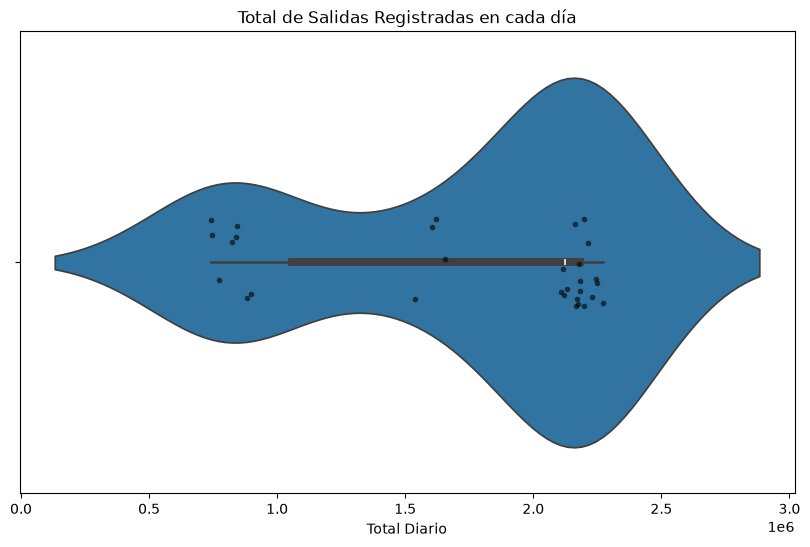

In [59]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_dia, x="total_dia")

sns.stripplot(
    data=df_dia, x="total_dia", color="black", 
    alpha=0.6,      
    jitter=True,    
    size=4         
)

plt.xlabel("Total Diario")
plt.title("Total de Salidas Registradas en cada día")
plt.show()

Se obtiene que en el mes de junio del 2025 el servicio de Transmilenio recibió en promedio 1.747.910 personas.

Se puede observar que los datos se distinguen en 3 grupos, los cuales corresponden de izquierda a derecha a:
- Domingos y festivos
- Sábados
- Lunes a Viernes

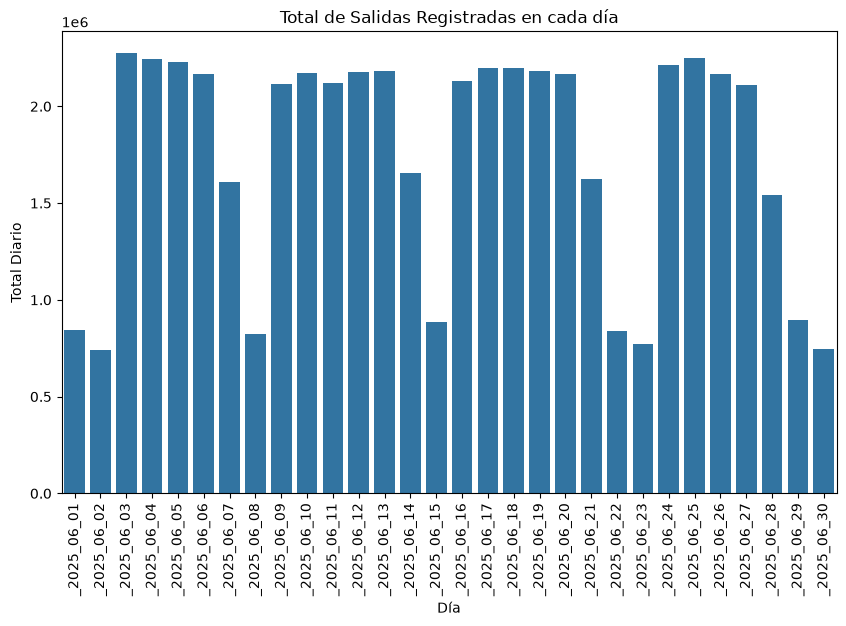

In [60]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_dia, y="total_dia", x='dia')

plt.xlabel("Día")
plt.ylabel("Total Diario")

plt.xticks(rotation=90, fontsize=10) 
plt.title("Total de Salidas Registradas en cada día")
plt.show()



- Los domingos y festivos son los días que reportan menor flujo de personas, los festivos especialmente; junio tiene 3 festivos por lo que en la gráfica de violin hay más puntos en el primer cuartil que en el segundo.
- Los siguientes son los sábados con un flujo de personas intermedio.
- Los días que reportan más salidas son los de entre semana (lunes a viernes).

Resulta curioso observar que el comportamiento es prácticamente el mismo cada semana con diferencias de pocas personas.

# Conclusiones
* Bogotá posee horas pico muy marcadas, fuera de ellas el flujo de personas reduce drásticamente generando dispersión en los datos.
* La zona que más emplea el servicio de Transmilenio es el sur, específicamente Soacha.
* El destino más concurrido es el centro de Bogotá, específicamente sobre la Caracas. Estas son las zonas laborales y universitarias principales de la capital.
* La estación con mayor flujo es la intermedia Banderas, puesto que tiene un objetivo similar al de un portal.
* En general el tamaño de las estaciones concuerda con su demanda, pero hay excepciones en Flores-Areandina culla infraestructura puede no ser suficiente para el flujo que recibe.
* Los cambios en el estado operativo de las estaciones se ha devido únicamente a la construcción de la primera línea del metro. Con excepción de Patio Bonito
* Transmilenio recibe mensualmente un promedio de $1.742.473$ habitantes. Su uso esta distingidamente dividido en días entre semana, sábados y lunes/festivos; siendo festivos los de menor flujo.